## What each metric means

Every method here returns a **cloud of N samples**, not one answer. So there are two separate
questions, and a metric answers one or the other:

> **1. Is the answer right?**  &nbsp;&nbsp; **2. Is the stated uncertainty honest?**

A method can ace the first and fail the second — that is the normal case here, and it is why
the bench metric alone is not enough.

### Is the answer right?

| metric | the question it answers | good |
|---|---|---|
| **`member_l2`** | *How far from the truth is a typical single sample?* This is **InverseBench's `relative l2`** — the number the benchmark reports. | low |
| **`mean_l2`** | *How far from the truth is the average of the samples?* Averaging cancels independent errors, so this is normally the better answer. | low |
| **`skill`** | The same as `mean_l2` but in the data's own units instead of a ratio. | low |

⚠️ **`member_l2` punishes uncertainty.** A method that returns N identical copies of its best
guess scores better on it than one that honestly spreads its samples out. So it cannot, on its
own, tell a good posterior from a collapsed one.

### Is the uncertainty honest?

| metric | the question it answers | good |
|---|---|---|
| **`spread`** | *How much do the samples disagree with each other?* | should **equal** the error |
| **`ssr`** | *Is that disagreement the right size?* It is `spread ÷ error`. | **1.0** |
| **`cover90`** | *Does the samples' 90% range actually contain the truth 90% of the time?* | **0.90** |
| **`rank`** | *Does the truth sit in the middle of the samples, or off to one side?* | **0.5** |

The intuition for `ssr`: if the samples really were draws from the right distribution, then how
far they scatter and how wrong the average is would be the *same size*. So

- `ssr < 1` → **over-confident**: the cloud is tighter than its own errors. It claims to know
  more than it does. **This is the failure mode this method has.**
- `ssr > 1` → over-dispersed: it hedges more than necessary.

`cover90` asks the same thing without assuming any particular shape, and `rank` distinguishes
*too narrow* (rank still 0.5) from *pointing the wrong way* (rank near 0 or 1).

### One number for both

| metric | the question it answers | good |
|---|---|---|
| **`crps`** | *Taking accuracy and honesty together, how good is this cloud?* | low |
| **`crps_n`** | the same, divided by the size of the truth, so problems can be compared | low |

CRPS is a **proper** score: unlike `member_l2` it **cannot be improved by collapsing the
ensemble**, and unlike `ssr` it cannot be improved by hedging. If you want a single column, it
is this one. (It is the *fair* version, which is corrected so that N=64 and N=512 are
comparable; the uncorrected one improves with N for free.)

### x space and y space

Every metric is computed twice:

- **`x_`** against the **ground truth** — did we recover the right state?
- **`y_`** against the **observation** — do our states reproduce the data we measured?

They can disagree, and the disagreement is informative: an inverse problem where many states
explain the same data can look good in `y` and poor in `x`. Note `y_` has a floor — the
observation is noisy, so even a perfect answer differs from it by one noise draw.

### InverseBench's own columns (`ib_` prefix)

`relative l2` (navier-stokes) · `psnr`, `ssim` (inv-scatter) · `cp_chi2`, `camp_chi2`, `psnr`,
`blur_psnr` (blackhole). PSNR is in dB and **higher is better**; chi-squared should be **near
1**, meaning the data are fitted to their own error bars.

⚠️ The blackhole chi-squares take the **best single member** of the cloud, so a wide,
badly-centred ensemble can score well on them while failing every column above.

<details><summary>Exact formulas</summary>

With `x*` the truth, `x_1..x_N` the samples, `x̄` their mean, `D` components:

```
member_l2 = mean_i ‖x_i − x*‖ / ‖x*‖          skill  = sqrt(mean_d (x̄ − x*)²)
mean_l2   = ‖x̄ − x*‖ / ‖x*‖                   spread = sqrt( (N+1)/N · mean_d Var_i(x_i) )
ssr       = spread / skill                    cover90 = mean_d 1[ q05 ≤ x* ≤ q95 ]
rank      = mean_d P(x_i < x*)                crps   = mean_i|x_i − x*| − ½ mean_ij|x_i − x_j|
```

`spread` carries the `(N+1)/N` factor (Fortin et al. 2014): an N-member sample variance
under-states the predictive variance by exactly that, so without it small ensembles would look
over-confident by construction and a sweep in N would be meaningless.
</details>

In [1]:
import sys, pathlib
ROOT = pathlib.Path('/mnt/home/gandry/kps/InverseBench')
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt, pandas as pd, numpy as np
import report_metrics as rm

CSV = ROOT / 'scripts' / 'metrics.csv'
RECOMPUTE = False            # True re-scores every result file (minutes)
RUNS = 'gen*'                # 'gen*' is the campaign; '*' takes every historical run

if RECOMPUTE or not CSV.exists():
    df = rm.collect(pattern=RUNS)
    df.to_csv(CSV, index=False)
else:
    df = pd.read_csv(CSV)

df['method'] = df.algo + '/' + df.run
print(f'{len(df)} runs x ids;', df.problem.value_counts().to_dict())

1040 runs x ids; {'inv-scatter': 500, 'blackhole': 500, 'navier-stokes': 40}


## The table

One row per (problem, method, N), averaged over test instances, with the standard error of
that mean — instance variation is the dominant noise source here (~2.3x seed variation), so
a difference smaller than a couple of `sem` is not a difference.

In [2]:
X = ['x_member_l2', 'x_mean_l2', 'x_skill', 'x_spread', 'x_ssr',
     'x_crps', 'x_crps_n', 'x_cover90', 'x_rank']
Y = ['y_member_l2', 'y_mean_l2', 'y_ssr', 'y_crps_n', 'y_cover90']
COLS = [c for c in X + Y if c in df]
KEY = ['problem', 'method', 'n']

# MEDIANS, NOT MEANS. A diverged run scores in the thousands and moves a 100-id mean by
# orders of magnitude -- blackhole KPSH has a few -- so the mean stops describing the
# typical instance. `diverged` counts them explicitly rather than letting them hide in an
# average, because how OFTEN a method blows up is itself a result.
g = df.groupby(KEY)
tbl = g[COLS].median()
tbl.insert(0, 'ids', g.size())
tbl.insert(1, 'diverged', g.x_mean_l2.apply(lambda s: int((s > 2).sum())))
display(tbl.round(4))

print('mean and its standard error, over NON-diverged ids only:')
ok = df[df.x_mean_l2 <= 2]
keep = [c for c in ('x_mean_l2', 'x_ssr', 'x_crps_n', 'y_mean_l2') if c in df]
display(pd.concat({'mean': ok.groupby(KEY)[keep].mean(),
                   'sem': ok.groupby(KEY)[keep].sem()}, axis=1).round(4))

ids  diverged  x_member_l2  x_mean_l2  \
problem       method        n                                            
blackhole     KPSG/gen      16   100         0       0.7285     0.5326   
              KPSH/gen_N128 128  100         4       0.3267     0.3245   
              KPSH/gen_N256 256  100         4       0.3355     0.3273   
              KPSH/gen_N512 512  100         0       0.3390     0.3269   
              KPSH/gen_N64  64   100         1       0.3491     0.3486   
inv-scatter   KPSG/gen      16   100         0       0.0353     0.0284   
              KPSH/gen_N128 128  100         0       0.3204     0.3189   
              KPSH/gen_N256 256  100         0       0.3063     0.2978   
              KPSH/gen_N512 512  100         0       0.3319     0.2885   
              KPSH/gen_N64  64   100         0       0.3477     0.3472   
navier-stokes KPSH/gen_N128 128   10         0       0.3623     0.3606   
              KPSH/gen_N256 256   10         0       0.2737     0.2692   
              KPSH/gen_N512 512   10         0       0.2450     0.2385   
              KPSH/gen_N64  64    10         0       0.4840     0.4836   

                                 x_skill  x_spread   x_ssr  x_crps  x_crps_n  \
problem       method        n                                                  
blackhole     KPSG/gen      16    0.0626    0.0596  0.9399  0.0158    0.1323   
              KPSH/gen_N128 128   0.0427    0.0046  0.1184  0.0158    0.1159   
              KPSH/gen_N256 256   0.0424    0.0085  0.2103  0.0139    0.1122   
              KPSH/gen_N512 512   0.0426    0.0129  0.3613  0.0130    0.1018   
              KPSH/gen_N64  64    0.0466    0.0030  0.0680  0.0179    0.1329   
inv-scatter   KPSG/gen      16    0.0090    0.0073  0.7912  0.0026    0.0083   
              KPSH/gen_N128 128   0.1034    0.0105  0.1113  0.0424    0.1336   
              KPSH/gen_N256 256   0.0955    0.0250  0.2727  0.0365    0.1149   
              KPSH/gen_N512 512   0.0912    0.0488  0.5016  0.0331    0.1029   
              KPSH/gen_N64  64    0.1109    0.0059  0.0536  0.0475    0.1479   
navier-stokes KPSH/gen_N128 128   1.8746    0.1703  0.0921  1.2500    0.2404   
              KPSH/gen_N256 256   1.3525    0.2414  0.2174  0.8959    0.1784   
              KPSH/gen_N512 512   1.2174    0.2886  0.2455  0.7628    0.1496   
              KPSH/gen_N64  64    2.4242    0.1070  0.0423  1.7155    0.3440   

                                 x_cover90  x_rank  y_member_l2  y_mean_l2  \
problem       method        n                                                
blackhole     KPSG/gen      16      0.8038  0.5053       0.0491     0.0351   
              KPSH/gen_N128 128     0.3297  0.4127       0.0485     0.0349   
              KPSH/gen_N256 256     0.5607  0.4711       0.0479     0.0345   
              KPSH/gen_N512 512     0.6721  0.4890       0.0489     0.0332   
              KPSH/gen_N64  64      0.1982  0.3865       0.0475     0.0352   
inv-scatter   KPSG/gen      16      0.8918  0.4939       0.0137     0.0096   
              KPSH/gen_N128 128     0.0776  0.1970       0.0754     0.0740   
              KPSH/gen_N256 256     0.1711  0.2007       0.0724     0.0691   
              KPSH/gen_N512 512     0.3118  0.2175       0.0798     0.0698   
              KPSH/gen_N64  64      0.0507  0.1999       0.0836     0.0831   
navier-stokes KPSH/gen_N128 128     0.1471  0.5040       0.1827     0.1805   
              KPSH/gen_N256 256     0.2828  0.4992       0.1491     0.1422   
              KPSH/gen_N512 512     0.3300  0.4992       0.1439     0.1342   
              KPSH/gen_N64  64      0.0685  0.4966       0.2495     0.2488   

                                  y_ssr  y_crps_n  y_cover90  
problem       method        n                                 
blackhole     KPSG/gen      16   1.0303    0.0105     0.8650  
              KPSH/gen_N128 128  1.0014    0.0106     0.8728  
              KPSH/gen_N256 256  1.0517    0.0108     0.9098  
   

mean and its standard error, over NON-diverged ids only:


mean                             \
                                x_mean_l2   x_ssr x_crps_n y_mean_l2   
problem       method        n                                          
blackhole     KPSG/gen      16     0.5521  0.9642   0.1407    0.0387   
              KPSH/gen_N128 128    0.4538  0.1237   0.1591    0.0369   
              KPSH/gen_N256 256    0.4392  0.8201   0.1515    0.0846   
              KPSH/gen_N512 512    0.4410  0.6381   0.1471    0.0782   
              KPSH/gen_N64  64     0.5103  0.0652   0.1840    0.0389   
inv-scatter   KPSG/gen      16     0.0285  0.7957   0.0083    0.0110   
              KPSH/gen_N128 128    0.2973  0.1282   0.1236    0.0706   
              KPSH/gen_N256 256    0.2754  0.3109   0.1056    0.0660   
              KPSH/gen_N512 512    0.2629  0.5256   0.0950    0.0639   
              KPSH/gen_N64  64     0.3259  0.0609   0.1400    0.0785   
navier-stokes KPSH/gen_N128 128    0.4614  0.0883   0.3252    0.2294   
              KPSH/gen_N256 256    0.3632  0.2178   0.2414    0.2240   
              KPSH/gen_N512 512    0.3059  0.2465   0.1991    0.1835   
              KPSH/gen_N64  64     0.6017  0.0376   0.4427    0.3293   

                                      sem                             
                                x_mean_l2   x_ssr x_crps_n y_mean_l2  
problem       method        n                                         
blackhole     KPSG/gen      16     0.0175  0.0201   0.0051    0.0018  
              KPSH/gen_N128 128    0.0329  0.0094   0.0111    0.0018  
              KPSH/gen_N256 256    0.0285  0.5314   0.0114    0.0464  
              KPSH/gen_N512 512    0.0294  0.2341   0.0117    0.0382  
              KPSH/gen_N64  64     0.0346  0.0031   0.0124    0.0018  
inv-scatter   KPSG/gen      16     0.0005  0.0047   0.0003    0.0004  
              KPSH/gen_N128 128    0.0087  0.0052   0.0057    0.0018  
              KPSH/gen_N256 256    0.0088  0.0111   0.0049    0.0019  
              KPSH/gen_N512 512    0.0087  0.0122   0.0046    0.0019  
              KPSH/gen_N64  64     0.0085  0.0024   0.0061    0.0017  
navier-stokes KPSH/gen_N128 128    0.0809  0.0107   0.0640    0.0435  
              KPSH/gen_N256 256    0.0808  0.0201   0.0563    0.0585  
              KPSH/gen_N512 512    0.0582  0.0229   0.0418    0.0363  
              KPSH/gen_N64  64     0.0700  0.0038   0.0598    0.0575

## Plots

Top row: whether the cloud is a posterior. Bottom row: accuracy, and whether x-space and
y-space agree. The dotted line in the SSR panels is calibration; below it the ensemble is
over-confident, which is this method's known failure mode.

In [3]:
# Palette: two categorical slots, fixed per METHOD so a colour always means the same thing.
# Validated all-pairs on a white surface (CVD dE 24.7, normal-vision dE 33.6, contrast >= 3:1).
C = {'KPSH': '#2a78d6', 'KPSG': '#eb6834', 'KPSD': '#1baf7a'}

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9, 'axes.titlesize': 9.5, 'axes.labelsize': 8.5,
    'axes.spines.top': False, 'axes.spines.right': False,     # recessive frame
    'axes.edgecolor': '#9a9a94', 'axes.labelcolor': '#5c5c57',
    'xtick.color': '#5c5c57', 'ytick.color': '#5c5c57', 'xtick.labelsize': 8,
    'ytick.labelsize': 8, 'grid.color': '#e4e4e0', 'grid.linewidth': 0.7,
    'legend.frameon': False, 'legend.fontsize': 8, 'lines.linewidth': 1.8,
})

def series(ax, gp, col, target=None, logy=False):
    r"""One line per algorithm over N. A single-N algorithm draws as a marker, not a line."""
    for algo, ga in gp.groupby('algo'):
        s = ga.groupby('n')[col]
        med, sem, xs = s.median(), s.sem(), s.median().index
        kw = dict(color=C.get(algo, '#5c5c57'), label=algo)
        if len(med) > 1:
            ax.errorbar(xs, med, sem, marker='o', ms=5, capsize=2, elinewidth=1, **kw)
            ax.annotate(algo, (xs[-1], med.iloc[-1]), textcoords='offset points',
                        xytext=(6, 0), color=kw['color'], fontsize=7.5, va='center')
        else:
            ax.errorbar(xs, med, sem, marker='D', ms=6, ls='none', capsize=2,
                        elinewidth=1, **kw)
            ax.annotate(f'{algo} (N={xs[0]})', (xs[0], med.iloc[0]),
                        textcoords='offset points', xytext=(8, 4), color=kw['color'],
                        fontsize=7.5)
    if target is not None:
        ax.axhline(target, color='#5c5c57', ls=(0, (4, 3)), lw=0.9, zorder=0)
        ax.annotate(f'calibrated = {target:g}', (0.02, target), xycoords=('axes fraction', 'data'),
                    textcoords='offset points', xytext=(0, 4), fontsize=7, color='#5c5c57')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('particles N')
    if logy:
        ax.set_yscale('log')
    ax.grid(axis='y', alpha=1.0)
    ax.set_axisbelow(True)
print('style ready')

style ready


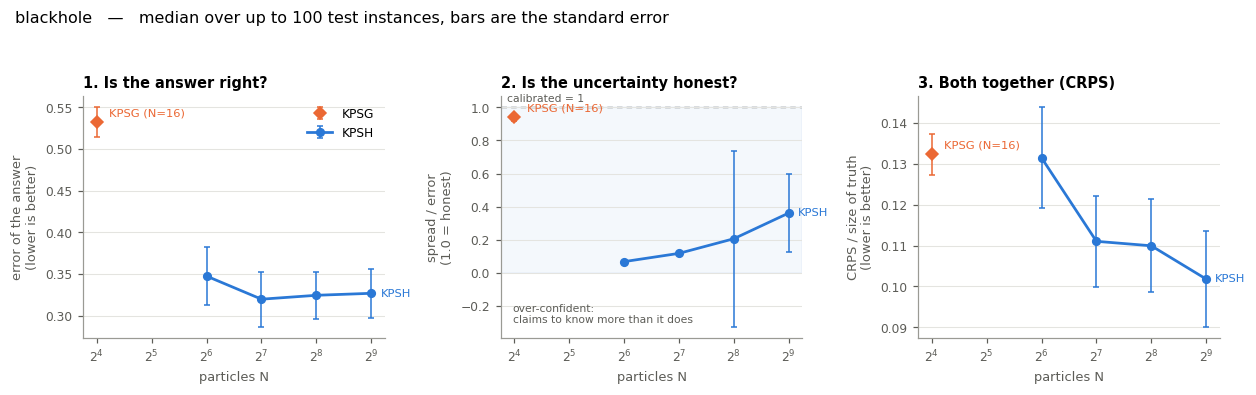

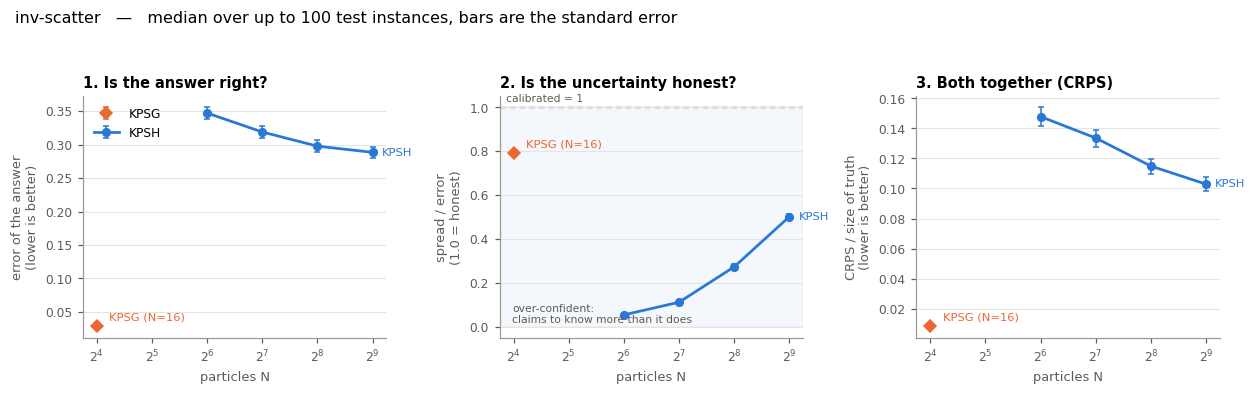

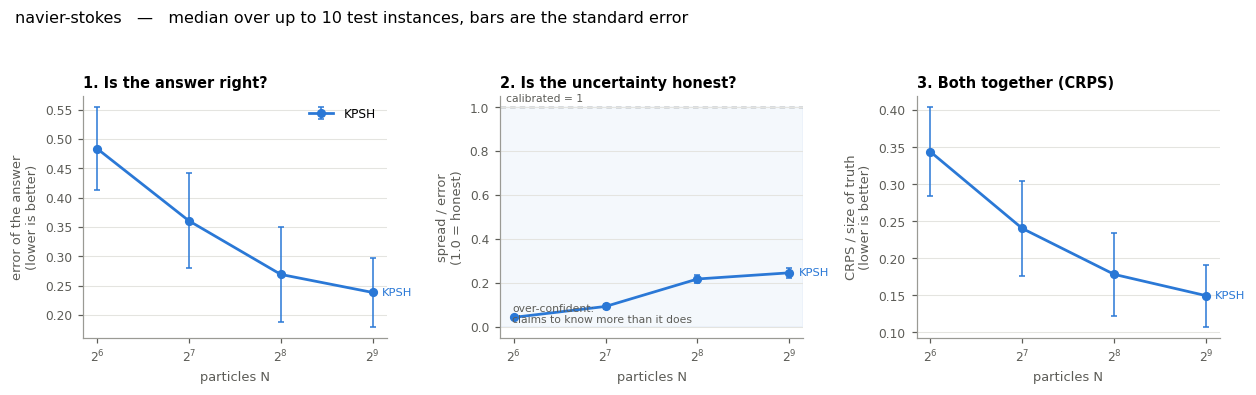

In [4]:
# THREE PANELS PER PROBLEM, one question each. Everything else lives in the table above.
ok = df[df.x_mean_l2 <= 2]                      # drop runs that blew up

for prob, gp in ok.groupby('problem'):
    fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.6))

    series(ax[0], gp, 'x_mean_l2')
    ax[0].set_title('1. Is the answer right?', loc='left', fontweight='bold')
    ax[0].set_ylabel('error of the answer\n(lower is better)')

    series(ax[1], gp, 'x_ssr', target=1.0)
    ax[1].set_title('2. Is the uncertainty honest?', loc='left', fontweight='bold')
    ax[1].set_ylabel('spread / error\n(1.0 = honest)')
    ax[1].axhspan(0, 1.0, color='#2a78d6', alpha=0.05, zorder=0)
    ax[1].annotate('over-confident:\nclaims to know more than it does', (0.04, 0.06),
                   xycoords='axes fraction', fontsize=7, color='#5c5c57')

    series(ax[2], gp, 'x_crps_n')
    ax[2].set_title('3. Both together (CRPS)', loc='left', fontweight='bold')
    ax[2].set_ylabel('CRPS / size of truth\n(lower is better)')

    n_ids = gp.groupby('n').size().max()
    fig.suptitle(f'{prob}   —   median over up to {n_ids} test instances, bars are the '
                 f'standard error', x=0.015, ha='left', fontsize=10.5)
    ax[0].legend(loc='best')
    plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

### More detail

The next two cells are the same data with more columns — the y-space metrics, coverage, and
InverseBench's own numbers. Skip them unless a question above needs following up.

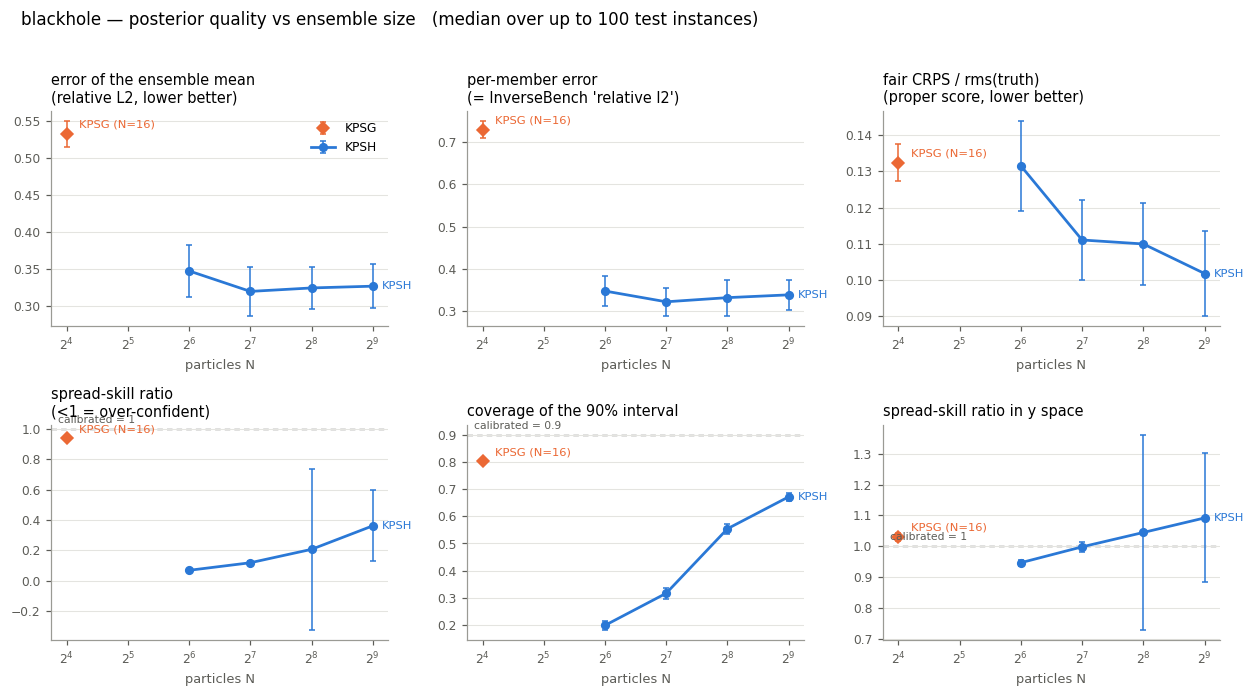

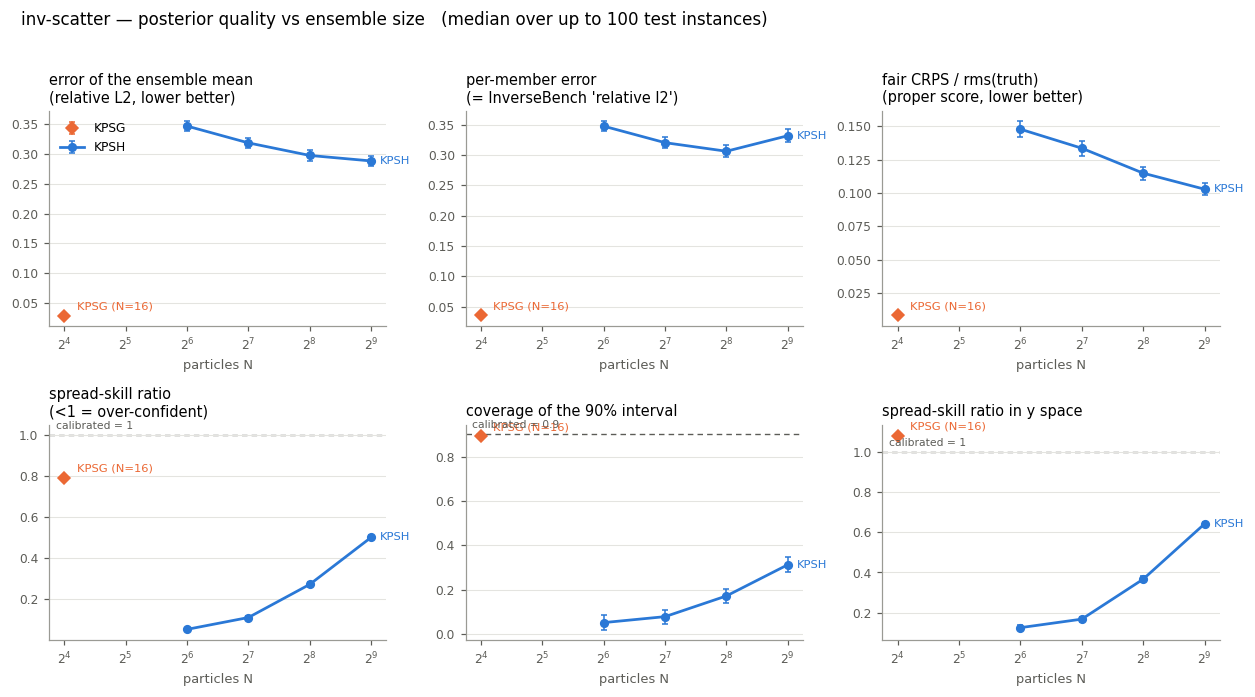

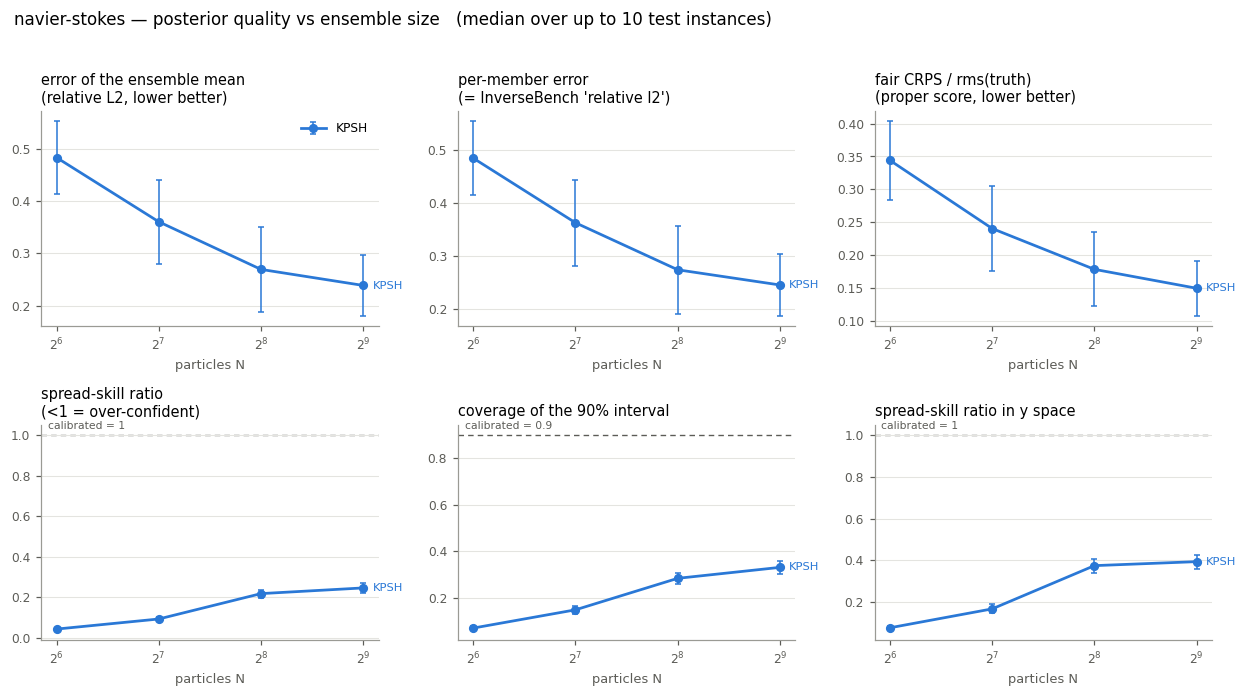

In [5]:
# ONE FIGURE PER PROBLEM. The three problems' errors live on different scales, so putting
# them on shared axes made every panel unreadable; small multiples keep each scale honest.
# Medians over test ids, error bars are the standard error of the median-ish (sem).
ok = df[df.x_mean_l2 <= 2]

PANELS = [('x_mean_l2', 'error of the ensemble mean\n(relative L2, lower better)', None),
          ('x_member_l2', "per-member error\n(= InverseBench 'relative l2')", None),
          ('x_crps_n', 'fair CRPS / rms(truth)\n(proper score, lower better)', None),
          ('x_ssr', 'spread-skill ratio\n(<1 = over-confident)', 1.0),
          ('x_cover90', 'coverage of the 90% interval', 0.90),
          ('y_ssr', 'spread-skill ratio in y space', 1.0)]

for prob, gp in ok.groupby('problem'):
    fig, ax = plt.subplots(2, 3, figsize=(11.5, 6.4))
    for a, (col, title, tgt) in zip(ax.ravel(), PANELS):
        if col not in gp:
            a.set_visible(False); continue
        series(a, gp, col, target=tgt)
        a.set_title(title, loc='left')
    n_ids = gp.groupby('n').size().max()
    fig.suptitle(f'{prob} — posterior quality vs ensemble size   '
                 f'(median over up to {n_ids} test instances)', x=0.02, ha='left',
                 fontsize=11)
    ax[0,0].legend(loc='best')
    plt.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

## Paired comparison between two methods

Aggregate means hide the blocking variable that matters. Two methods run on the same test
ids should be compared **per id**: the paired difference isolates the method change instead
of measuring it on top of instance variation.

x_mean_l2:  KPSH/gen_N512 - KPSH/gen_N128
  mean -0.0317   sem 0.0156   wins 157/206   (206 paired ids)


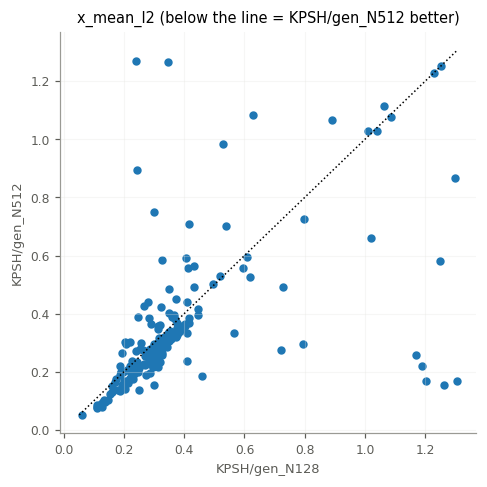

In [6]:
A, B = 'KPSH/gen_N512', 'KPSH/gen_N128'      # edit these
METRIC = 'x_mean_l2'

pair = (df[df.method.isin([A, B])]
        .pivot_table(index=['problem', 'id'], columns='method', values=METRIC))
pair = pair.dropna()
PROBLEM = None                              # None pools problems -- usually wrong
if PROBLEM:
    pair = pair.loc[PROBLEM]
pair = pair[(pair < 2).all(axis=1)]         # drop diverged ids from the pairing

if pair.empty:
    print('no ids in common — check the method names against the table above')
else:
    d = pair[A] - pair[B]
    print(f'{METRIC}:  {A} - {B}\n'
          f'  mean {d.mean():+.4f}   sem {d.sem():.4f}   '
          f'wins {int((d < 0).sum())}/{len(d)}   ({len(d)} paired ids)')
    fig, a = plt.subplots(figsize=(4.5, 4.5))
    a.scatter(pair[B], pair[A], s=20)
    lo, hi = pair.values.min(), pair.values.max()
    a.plot([lo, hi], [lo, hi], 'k:', lw=1)
    a.set_xlabel(B); a.set_ylabel(A); a.set_title(f'{METRIC} (below the line = {A} better)')
    a.grid(alpha=.3); plt.tight_layout(); plt.show()

## InverseBench's own problem-specific metrics

Run through the bench's **own evaluator**, so these are its numbers and not a
reimplementation. They need the forward operator, which is why they are a separate pass
(blackhole loads ehtim and its uvfits; allow a minute).

| problem | columns | note |
|---|---|---|
| navier-stokes | `relative l2` | mean over members — identical to `x_member_l2` above |
| inv-scatter | `psnr`, `ssim` | per member on `clip(0,1)`, then averaged |
| blackhole | `cp_chi2`, `camp_chi2` | **best member** (`.min()` over the ensemble) |
| blackhole | `psnr`, `blur_psnr (f=10/15/20)` | maximised over blur factors |

Read the blackhole chi-squares with care: `.min()` over the cloud rewards having *one*
good member, so a wide, badly-centred ensemble can score well on them while failing every
distributional column. Chi-square near 1 is the target (the data are fitted to their error
bars); far below 1 is over-fitting the noise.

In [7]:
OFFICIAL_CSV = ROOT / 'scripts' / 'metrics_official.csv'
RECOMPUTE_OFFICIAL = False
LIMIT = None                 # e.g. 10 for a quick look; None is every id

if RECOMPUTE_OFFICIAL or not OFFICIAL_CSV.exists():
    off = rm.collect(pattern=RUNS, with_official=True, limit=LIMIT)
    off.to_csv(OFFICIAL_CSV, index=False)
else:
    off = pd.read_csv(OFFICIAL_CSV)

off['method'] = off.algo + '/' + off.run
IB = sorted(c for c in off.columns if c.startswith('ib_'))
print(IB)

['ib_blur_psnr (f=10)', 'ib_blur_psnr (f=15)', 'ib_blur_psnr (f=20)', 'ib_camp_chi2', 'ib_cp_chi2', 'ib_psnr', 'ib_relative l2', 'ib_ssim']


In [8]:
# One table per problem: the bench's columns beside the distributional ones, so a method
# that wins on psnr while its cloud has collapsed is visible in one glance.
SHOW = ['x_member_l2', 'x_mean_l2', 'x_ssr', 'x_crps_n', 'x_cover90', 'y_mean_l2']

for prob, gp in off.groupby('problem'):
    cols = [c for c in IB if gp[c].notna().any()] + [c for c in SHOW if c in gp]
    t = gp.groupby(['method', 'n'])[cols].median()
    t.insert(0, 'ids', gp.groupby(['method', 'n']).size())
    t.insert(1, 'diverged', gp.groupby(['method', 'n']).x_mean_l2.apply(
        lambda s: int((s > 2).sum())))
    print(f'\n=== {prob}   (medians)')
    display(t.round(4))


=== blackhole   (medians)


,,ids,diverged,ib_blur_psnr (f=10),ib_blur_psnr (f=15),ib_blur_psnr (f=20),ib_camp_chi2,ib_cp_chi2,ib_psnr,x_member_l2,x_mean_l2,x_ssr,x_crps_n,x_cover90,y_mean_l2
method,n,,,,,,,,,,,,,,
KPSG/gen,16,3,0,31.9516,37.5916,39.8574,1.0123,4.7531,31.9516,0.6921,0.4942,1.1747,0.0901,0.8105,0.0514
KPSH/gen_N128,128,3,0,31.7038,38.7211,41.0540,1.0007,1.8362,31.7038,0.2248,0.2201,0.1782,0.0943,0.3928,0.0329
KPSH/gen_N256,256,3,0,32.3937,38.5243,40.0002,1.0634,2.7875,32.3937,0.2706,0.2599,0.2844,0.1026,0.6057,0.0320
KPSH/gen_N512,512,3,0,33.5525,42.5114,45.0010,1.0262,1.4474,33.5525,0.3218,0.3040,0.3611,0.0952,0.7112,0.0328
KPSH/gen_N64,64,3,0,26.1013,31.0860,33.7918,1.0445,30.9337,26.1013,0.9265,0.9261,0.0332,0.3479,0.2129,0.0338



=== inv-scatter   (medians)


,,ids,diverged,ib_psnr,ib_ssim,x_member_l2,x_mean_l2,x_ssr,x_crps_n,x_cover90,y_mean_l2
method,n,,,,,,,,,,
KPSG/gen,16,3,0,38.6329,0.9961,0.0339,0.0270,0.8131,0.0084,0.8917,0.0095
KPSH/gen_N128,128,3,0,19.5778,0.7738,0.3215,0.3200,0.1196,0.1309,0.0758,0.0745
KPSH/gen_N256,256,3,0,20.1729,0.7756,0.3003,0.2892,0.2950,0.1119,0.2200,0.0676
KPSH/gen_N512,512,3,0,19.5159,0.7446,0.3239,0.2920,0.4858,0.1052,0.2927,0.0681
KPSH/gen_N64,64,3,0,18.7841,0.7544,0.3523,0.3518,0.0517,0.1475,0.0744,0.0829



=== navier-stokes   (medians)


,,ids,diverged,ib_relative l2,x_member_l2,x_mean_l2,x_ssr,x_crps_n,x_cover90,y_mean_l2
method,n,,,,,,,,,
KPSH/gen_N128,128,3,0,0.4595,0.4595,0.4585,0.0664,0.3027,0.1243,0.2003
KPSH/gen_N256,256,3,0,0.2773,0.2773,0.2723,0.2131,0.1799,0.2844,0.1516
KPSH/gen_N512,512,3,0,0.2581,0.2581,0.2508,0.2456,0.1589,0.3146,0.1461
KPSH/gen_N64,64,3,0,0.4498,0.4498,0.4493,0.0474,0.3045,0.0789,0.2022


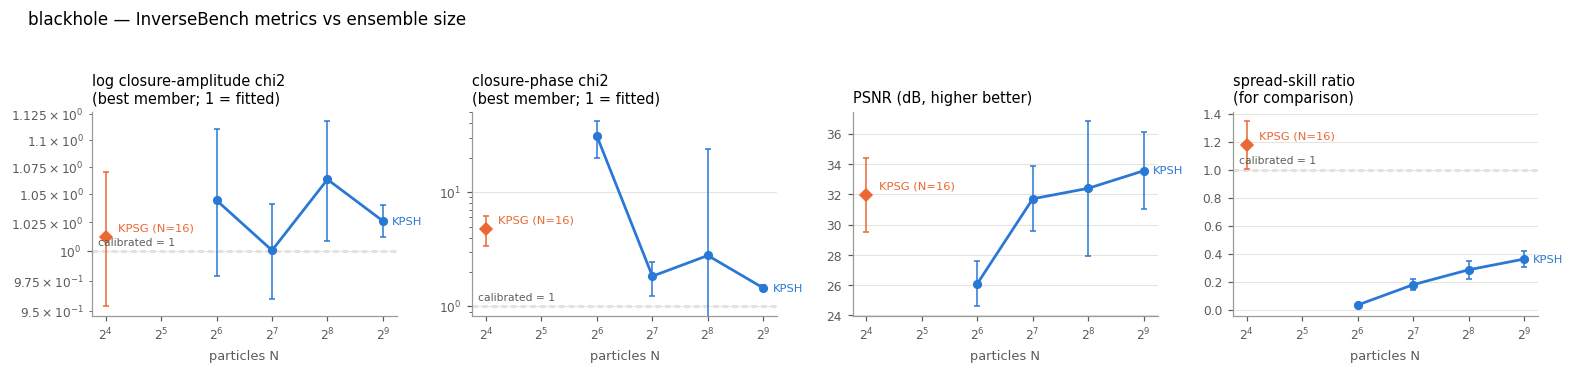

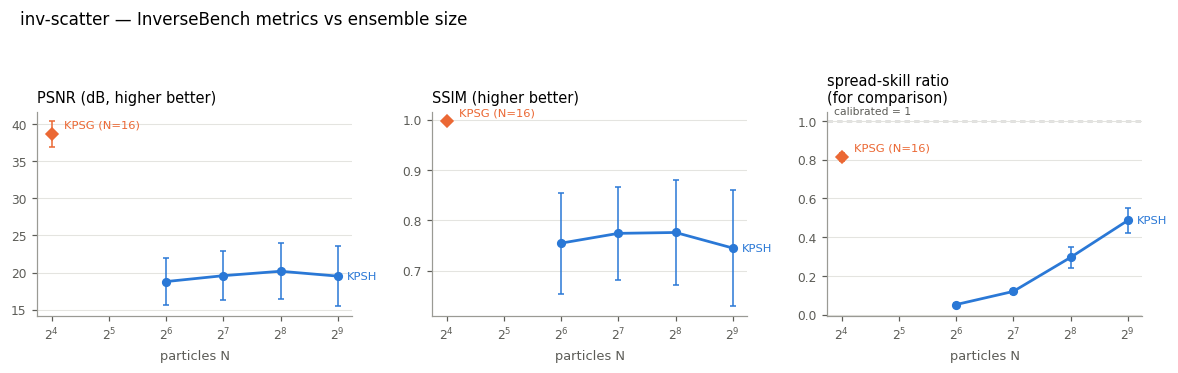

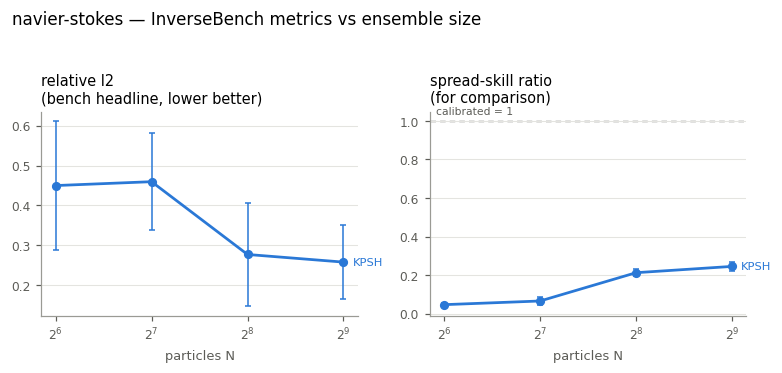

In [9]:
# The bench's own columns, same layout. A curve that improves here while SSR stays flat is
# buying point accuracy without buying a posterior -- which is what the bench metric rewards.
okf = off[off.x_mean_l2 <= 2]
LABEL = {'ib_relative l2': "relative l2\n(bench headline, lower better)",
         'ib_psnr': 'PSNR (dB, higher better)', 'ib_ssim': 'SSIM (higher better)',
         'ib_cp_chi2': 'closure-phase chi2\n(best member; 1 = fitted)',
         'ib_camp_chi2': 'log closure-amplitude chi2\n(best member; 1 = fitted)'}

for prob, gp in okf.groupby('problem'):
    cols = [c for c in IB if gp[c].notna().any() and 'blur' not in c]
    if not cols:
        continue
    fig, ax = plt.subplots(1, len(cols) + 1, figsize=(3.6 * (len(cols) + 1), 3.4),
                           squeeze=False)
    for a, c in zip(ax[0], cols):
        series(a, gp, c, target=1.0 if 'chi2' in c else None, logy='chi2' in c)
        a.set_title(LABEL.get(c, c), loc='left')
    series(ax[0][-1], gp, 'x_ssr', target=1.0)
    ax[0][-1].set_title('spread-skill ratio\n(for comparison)', loc='left')
    fig.suptitle(f'{prob} — InverseBench metrics vs ensemble size', x=0.02, ha='left',
                 fontsize=11)
    plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

## Caveats

- **y space has a floor.** `recon_obs` is the operator applied *with* its observation noise,
  so a perfect reconstruction still differs from `observation` by one noise draw. A y error
  below `sigma_noise*sqrt(dim)/||y||` means the noise is being fitted.
- **The blackhole samples used an isotropic `Sigma_y`**, measured at 24.4 against a median
  channel variance of 0.407 on that operator — the case where the assumption is least
  defensible. Read those rows with that in mind.
- **The bench's blackhole metrics are not in the table.** `cp_chi2`, `camp_chi2` and the
  blur-maximised psnr go through the forward operator, and its chi-squares are a *best member*
  (`.min()` over the ensemble), not an ensemble score. Get them with
  `rm.collect(with_official=True)`, which runs the bench's own evaluator.
- **The NS harness is non-deterministic**: identical runs differ, err sd 0.041 per run. These
  runs were not made under `run_det.py`, so per-id numbers carry that noise.